# Understanding Agricultural Land Cover Changes

This tutorial helps you understand agricultural land cover data using two complementary datasets: CORINE land cover and satellite-based land cover. You'll explore and compare these datasets to understand their characteristics, differences, and temporal dynamics.

We'll work with:
- **CORINE Land Cover**: European land cover maps (1990, 2000, 2006, 2012, 2018) with detailed classification
- **Satellite Land Cover**: Global satellite-based land cover (1992-2022) at 300m resolution

**Prerequisites**: We'll use preprocessed data for the region "Central Greece" (NUTS2 region "EL64"). If you change the region, please download and process the agricultural land data for your region using the how-to guides:
- [Agricultural land from CORINE](../how-to-guides/agricultural_land_corine.ipynb)
- [Agricultural land from satellite data](../how-to-guides/agricultural_land_satellite.ipynb)

**What you'll learn**:
- Load and visualize agricultural land timeseries from CSV files
- Explore spatial agricultural land distributions from raster data
- Compare different land cover datasets (CORINE vs. satellite)
- Understand temporal patterns in agricultural land changes
- Create interactive maps of land cover

## Setup

### User settings

In [2]:
admin_id = "EL64"  # Central Greece

### Load libraries

In [3]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import regionmask
from pathlib import Path
import rioxarray as rxr
import os

# Set up data directories
data_dir = Path("../data")
corine_output_dir = data_dir / admin_id / "corine_land_cover"
satellite_output_dir = data_dir / admin_id / "satellite_land_cover"

print(f"\nData directories:")
print(f"  CORINE: {corine_output_dir}")
print(f"  Satellite: {satellite_output_dir}")


Data directories:
  CORINE: ../data/EL64/corine_land_cover
  Satellite: ../data/EL64/satellite_land_cover


### Load region shapefile

In [3]:
# Read NUTS shapefiles
regions_dir = data_dir / 'regions'
nuts_shp = regions_dir / 'NUTS_RG_20M_2024_4326' / 'NUTS_RG_20M_2024_4326.shp'
nuts_gdf = gpd.read_file(nuts_shp)

# Select the region of interest
sel_gdf = nuts_gdf[nuts_gdf['NUTS_ID'] == admin_id]
print(f"Region: {sel_gdf['NUTS_NAME'].values[0]} ({admin_id})")
print(f"Country: {sel_gdf['CNTR_CODE'].values[0]}")
lon_min, lat_min, lon_max, lat_max = sel_gdf.geometry.total_bounds

# Create a regionmask from the admin region geometry
admin_mask = regionmask.from_geopandas(sel_gdf, names='NUTS_ID')

Region: Στερεά Ελλάδα (EL64)
Country: EL


## Load Regional Agricultural Land Timeseries

First, let's load the processed CSV files created by the how-to guides.

### Load CORINE land cover data

In [4]:
# Load CORINE CSV files
csv_corine_categories = corine_output_dir / "land_cover_categories.csv"
csv_corine_agri = corine_output_dir / "agricultural_land_breakdown.csv"

# Read the data
df_corine_categories = pd.read_csv(csv_corine_categories)
df_corine_agri = pd.read_csv(csv_corine_agri)

print("CORINE land cover categories:")
print(f"  Years: {df_corine_categories['year'].min():.0f} - {df_corine_categories['year'].max():.0f}")
print(f"  Records: {len(df_corine_categories)}")
print(f"\nMain categories sample:")
print(df_corine_categories.head())
print(f"\nAgricultural breakdown sample:")
print(df_corine_agri.head())

CORINE land cover categories:
  Years: 1990 - 2018
  Records: 5

Main categories sample:
   year  agricultural     forest     urban     water
0  1990     33.279219  62.715590  1.252794  1.067083
1  2000     33.257153  62.504301  1.510422  1.055861
2  2006     32.446728  62.442879  2.181934  1.109056
3  2012     31.755714  62.452383  2.562456  1.105405
4  2018     31.745346  62.425693  2.620222  1.105405

Agricultural breakdown sample:
   year  Non-irrigated arable  Permanently irrigated  Rice fields  Vineyards  \
0  1990              9.675677               3.523386     0.103912   0.095955   
1  2000              9.678976               3.548181     0.072627   0.097757   
2  2006              5.558817               7.323455     0.230085   0.091398   
3  2012              5.307652               7.742775     0.228292   0.098860   
4  2018              5.304568               7.733826     0.228292   0.098860   

   Fruit trees  Olive groves  Pastures  Annual+permanent crops  \
0     0.163262

### Load satellite land cover data

In [6]:
# Load satellite CSV file
csv_satellite = satellite_output_dir / f"agricultural_land_fraction_{admin_id}.csv"

# Read the data
df_satellite = pd.read_csv(csv_satellite)
# Convert fraction to percentage for easier comparison
df_satellite['agricultural'] = df_satellite['ag_fraction'] * 100

print("Satellite land cover data:")
print(f"  Years: {df_satellite['year'].min():.0f} - {df_satellite['year'].max():.0f}")
print(f"  Records: {len(df_satellite)}")
print(f"\nSample:")
print(df_satellite.head())

Satellite land cover data:
  Years: 1992 - 2022
  Records: 31

Sample:
   year  ag_fraction  agricultural
0  1992     0.304581     30.458114
1  1993     0.304572     30.457187
2  1994     0.304567     30.456723
3  1995     0.301157     30.115664
4  1996     0.298070     29.807042


## Compare Agricultural Land Timeseries

Let's visualize and compare the two datasets to understand their differences and similarities.

### Visualize both datasets

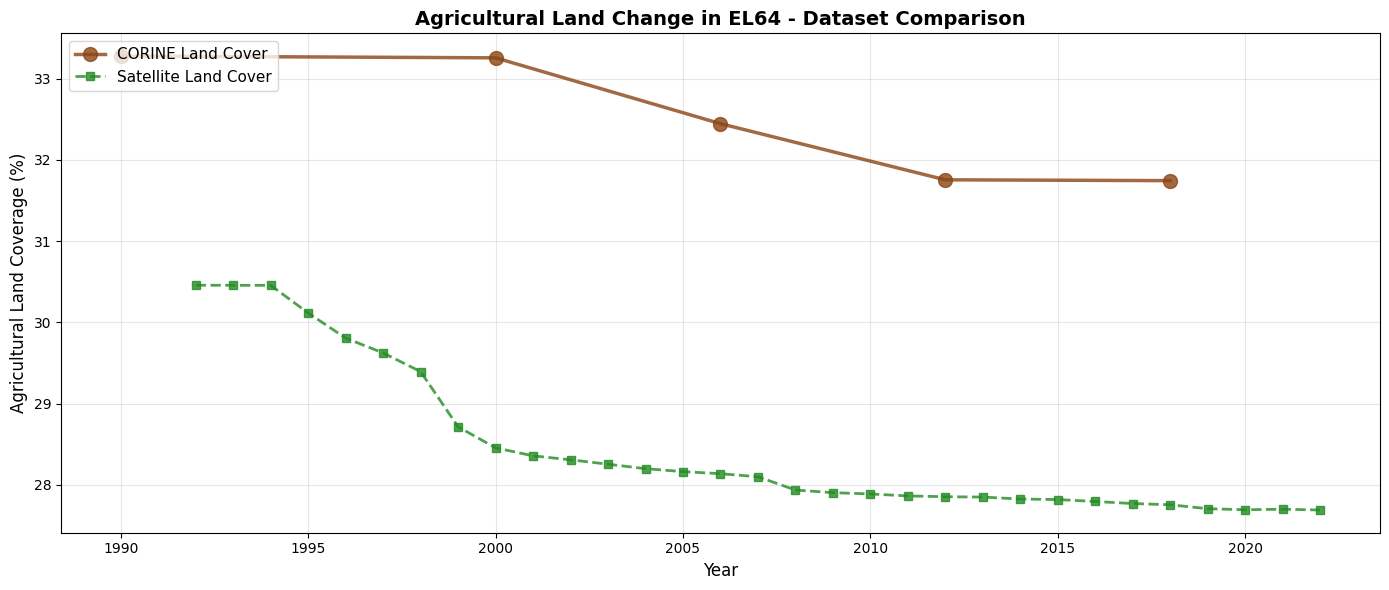

In [7]:
fig, ax = plt.subplots(figsize=(14, 6))

# Plot CORINE agricultural land
ax.plot(df_corine_categories['year'], df_corine_categories['agricultural'], 
        marker='o', linewidth=2.5, markersize=10, label='CORINE Land Cover', 
        color='#8B4513', linestyle='-', alpha=0.8)

# Plot satellite agricultural land
ax.plot(df_satellite['year'], df_satellite['agricultural'], 
        marker='s', linewidth=2, markersize=6, label='Satellite Land Cover', 
        color='#228B22', linestyle='--', alpha=0.8)

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Agricultural Land Coverage (%)', fontsize=12)
ax.set_title(f'Agricultural Land Change in {admin_id} - Dataset Comparison', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Quantify differences

For overlapping years, let's calculate the differences between the two datasets.

In [8]:
# Find overlapping years (CORINE years within satellite range)
corine_years = df_corine_categories['year'].values
satellite_years = df_satellite['year'].values

# Get closest satellite values for each CORINE year
comparison_data = []
for corine_year in corine_years:
    # Find exact match or closest year in satellite data
    if corine_year in satellite_years:
        sat_val = df_satellite[df_satellite['year'] == corine_year]['agricultural'].values[0]
        cor_val = df_corine_categories[df_corine_categories['year'] == corine_year]['agricultural'].values[0]
        
        comparison_data.append({
            'year': corine_year,
            'corine': cor_val,
            'satellite': sat_val,
            'difference': sat_val - cor_val,
            'percent_diff': ((sat_val - cor_val) / cor_val) * 100
        })

df_comparison = pd.DataFrame(comparison_data)

print("Dataset Comparison (overlapping years):")
print("="*90)
print(f"{'Year':<8} {'CORINE (%)':>12} {'Satellite (%)':>14} {'Diff (pp)':>12} {'Diff (%)':>12}")
print("-"*90)

for _, row in df_comparison.iterrows():
    print(f"{row['year']:<8.0f} {row['corine']:>12.2f} {row['satellite']:>14.2f} "
          f"{row['difference']:>12.2f} {row['percent_diff']:>11.2f}%")

print("\nSummary Statistics:")
print(f"  Mean absolute difference: {df_comparison['difference'].abs().mean():.2f} percentage points")
print(f"  Mean relative difference: {df_comparison['percent_diff'].abs().mean():.2f}%")
print(f"  Max difference: {df_comparison['difference'].abs().max():.2f} pp in {df_comparison.loc[df_comparison['difference'].abs().idxmax(), 'year']:.0f}")

Dataset Comparison (overlapping years):
Year       CORINE (%)  Satellite (%)    Diff (pp)     Diff (%)
------------------------------------------------------------------------------------------
2000            33.26          28.46        -4.80      -14.43%
2006            32.45          28.14        -4.31      -13.28%
2012            31.76          27.85        -3.90      -12.28%
2018            31.75          27.76        -3.99      -12.57%

Summary Statistics:
  Mean absolute difference: 4.25 percentage points
  Mean relative difference: 13.14%
  Max difference: 4.80 pp in 2000


## Explore CORINE Land Cover Categories

CORINE provides detailed information about different land cover types beyond just agricultural land.

### Plot all land cover categories

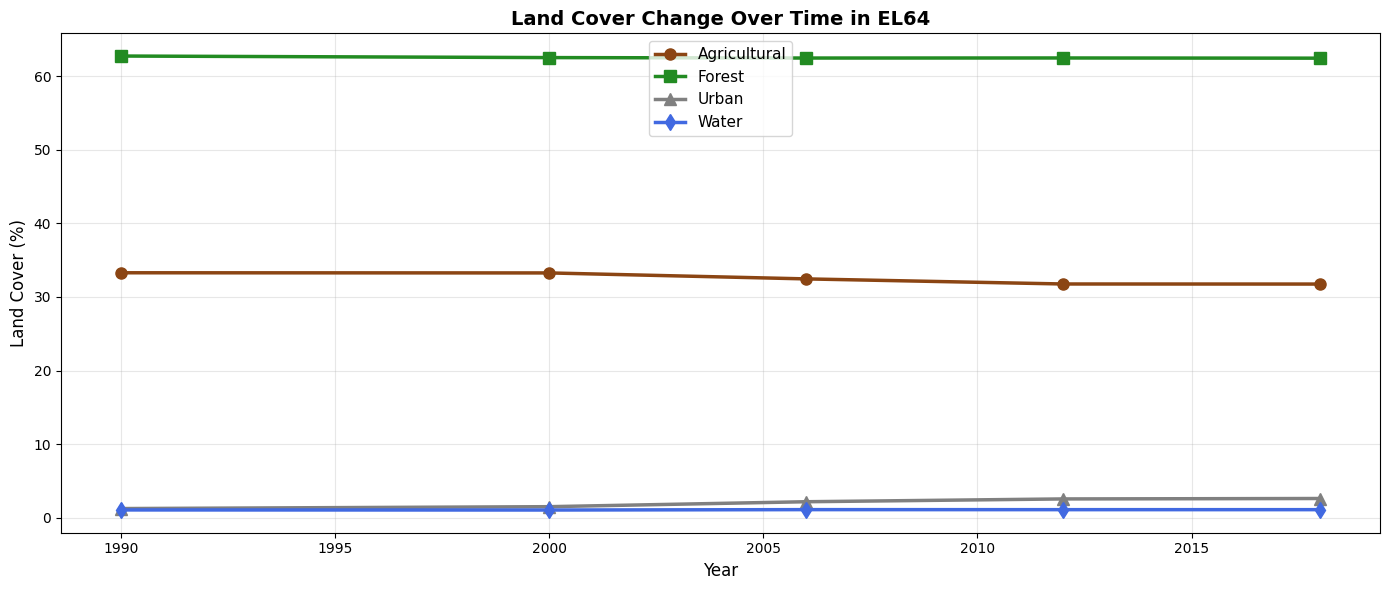

Land Cover Trends (1990 to 2018):
  Agricultural: 33.28% → 31.75% (change: -1.53 pp)
  Forest: 62.72% → 62.43% (change: -0.29 pp)
  Urban: 1.25% → 2.62% (change: +1.37 pp)
  Water: 1.07% → 1.11% (change: +0.04 pp)


In [9]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df_corine_categories['year'], df_corine_categories['agricultural'], 
        marker='o', linewidth=2.5, markersize=8, label='Agricultural', color='#8B4513')
ax.plot(df_corine_categories['year'], df_corine_categories['forest'], 
        marker='s', linewidth=2.5, markersize=8, label='Forest', color='#228B22')
ax.plot(df_corine_categories['year'], df_corine_categories['urban'], 
        marker='^', linewidth=2.5, markersize=8, label='Urban', color='#808080')
ax.plot(df_corine_categories['year'], df_corine_categories['water'], 
        marker='d', linewidth=2.5, markersize=8, label='Water', color='#4169E1')

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Land Cover (%)', fontsize=12)
ax.set_title(f'Land Cover Change Over Time in {admin_id}', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print trends
print("Land Cover Trends (1990 to 2018):")
for category in ['agricultural', 'forest', 'urban', 'water']:
    start_val = df_corine_categories[category].iloc[0]
    end_val = df_corine_categories[category].iloc[-1]
    change = end_val - start_val
    print(f"  {category.capitalize()}: {start_val:.2f}% → {end_val:.2f}% (change: {change:+.2f} pp)")

### Detailed agricultural land breakdown

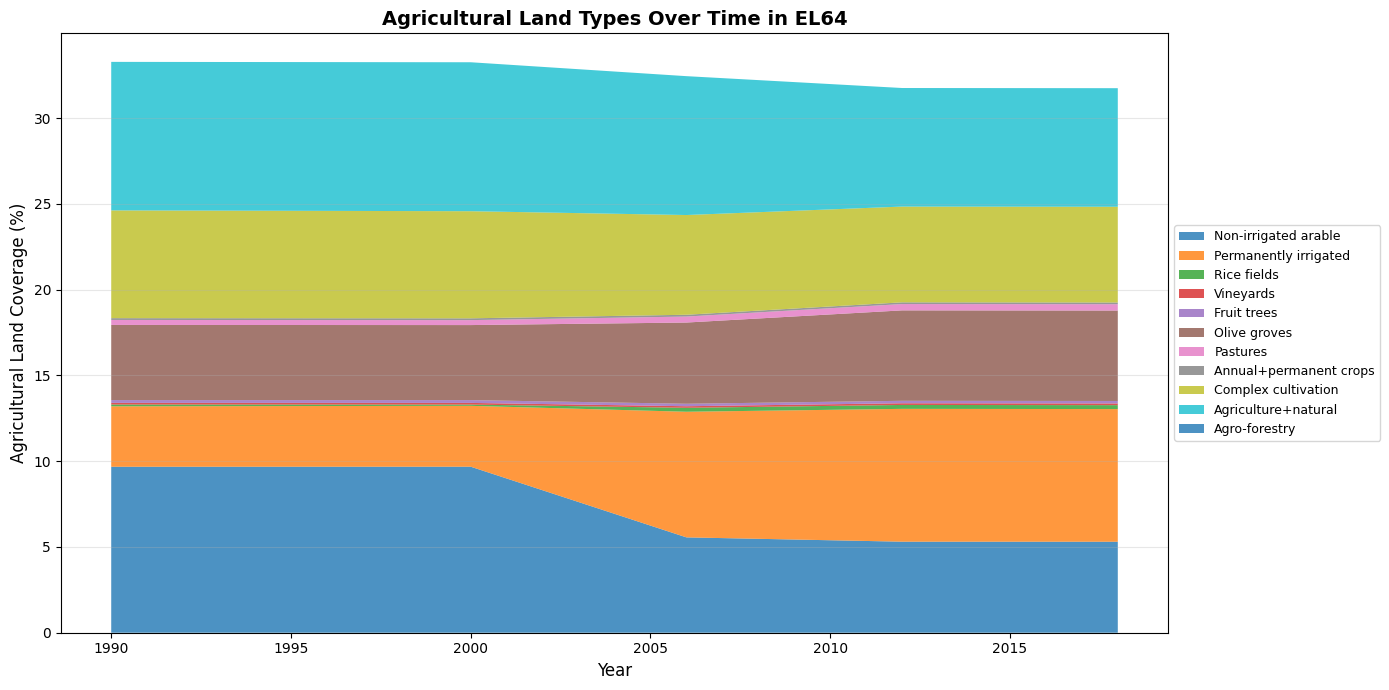


Agricultural land types (2018):
  Non-irrigated arable: 5.30%
  Permanently irrigated: 7.73%
  Olive groves: 5.27%
  Complex cultivation: 5.58%
  Agriculture+natural: 6.91%


In [10]:
# Stacked area plot of agricultural land types
fig, ax = plt.subplots(figsize=(14, 7))

# Prepare data for stacking
agri_cols = [col for col in df_corine_agri.columns if col != 'year']
years = df_corine_agri['year'].values

# Create stacked area plot
ax.stackplot(years, 
             *[df_corine_agri[col].values for col in agri_cols],
             labels=agri_cols,
             alpha=0.8)

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Agricultural Land Coverage (%)', fontsize=12)
ax.set_title(f'Agricultural Land Types Over Time in {admin_id}', fontsize=14, fontweight='bold')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Print summary of agricultural types
print("\nAgricultural land types (2018):")
latest_agri = df_corine_agri.iloc[-1]
for col in agri_cols:
    val = latest_agri[col]
    if val > 0.5:  # Only show significant types
        print(f"  {col}: {val:.2f}%")

## Interactive Map of CORINE Land Cover

Let's create an interactive map showing the spatial distribution of CORINE land cover for the latest available year (2018).

In [11]:
# Install folium if not available
try:
    import folium
    from folium import plugins
except ImportError:
    !pip install folium
    import folium
    from folium import plugins

In [12]:
# Load CORINE land cover raster (latest year)
corine_tif = corine_output_dir / f"corine_landcover_{admin_id}.tif"
corine_raster = rxr.open_rasterio(corine_tif)
corine_raster = corine_raster.squeeze()

print(f"Loaded CORINE raster: {corine_tif.name}")
print(f"Shape: {corine_raster.shape}")
print(f"Coordinate ranges: lon=[{float(corine_raster.x.min()):.2f}, {float(corine_raster.x.max()):.2f}], lat=[{float(corine_raster.y.min()):.2f}, {float(corine_raster.y.max()):.2f}]")
print(f"Unique classes present: {np.unique(corine_raster.values[~np.isnan(corine_raster.values)])}")

Loaded CORINE raster: corine_landcover_EL64.tif
Shape: (1650, 3105)
Coordinate ranges: lon=[21.26, 24.79], lat=[37.93, 39.43]
Unique classes present: [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17. 18.
 19. 20. 21. 23. 24. 25. 26. 27. 28. 29. 30. 31. 32. 35. 37. 40. 41. 42.
 43. 44.]


In [13]:
# Define CORINE class names and colors
corine_classes = {
    1: ('Continuous urban fabric', '#E6004D'),
    2: ('Discontinuous urban fabric', '#FF0000'),
    3: ('Industrial or commercial units', '#CC4DF2'),
    4: ('Road and rail networks', '#CC0000'),
    5: ('Port areas', '#E6CCCC'),
    6: ('Airports', '#E6CCE6'),
    7: ('Mineral extraction sites', '#A600CC'),
    8: ('Dump sites', '#A64DCC'),
    9: ('Construction sites', '#FF4DFF'),
    10: ('Green urban areas', '#FFA6FF'),
    11: ('Sport and leisure facilities', '#FFE6FF'),
    12: ('Non-irrigated arable land', '#FFFFA8'),
    13: ('Permanently irrigated land', '#FFFF00'),
    14: ('Rice fields', '#E6E600'),
    15: ('Vineyards', '#E68000'),
    16: ('Fruit trees and berry plantations', '#F2A64D'),
    17: ('Olive groves', '#E6A600'),
    18: ('Pastures', '#E6E64D'),
    19: ('Annual crops associated with permanent crops', '#FFE6A6'),
    20: ('Complex cultivation patterns', '#FFE6CC'),
    21: ('Land principally occupied by agriculture', '#F2CC80'),
    22: ('Agro-forestry areas', '#80FF00'),
    23: ('Broad-leaved forest', '#00A600'),
    24: ('Coniferous forest', '#4DFF00'),
    25: ('Mixed forest', '#CCF24D'),
    26: ('Natural grasslands', '#A6FF80'),
    27: ('Moors and heathland', '#A6E64D'),
    28: ('Sclerophyllous vegetation', '#A6F200'),
    29: ('Transitional woodland-shrub', '#00CCF2'),
    30: ('Beaches, dunes, sands', '#CCE6FF'),
    31: ('Bare rocks', '#4D4DFF'),
    32: ('Sparsely vegetated areas', '#CCCCCC'),
    33: ('Burnt areas', '#000000'),
    34: ('Glaciers and perpetual snow', '#4DFF4D'),
    35: ('Inland marshes', '#00CCF2'),
    36: ('Peat bogs', '#80F2E6'),
    37: ('Salt marshes', '#00FFA6'),
    38: ('Salines', '#A6FFE6'),
    39: ('Intertidal flats', '#E6F2FF'),
    40: ('Water courses', '#00CCF2'),
    41: ('Water bodies', '#80F2E6'),
    42: ('Coastal lagoons', '#00FFA6'),
    43: ('Estuaries', '#A6FFE6'),
    44: ('Sea and ocean', '#E6F2FF')
}

# Calculate center of region
center_lat = (lat_min + lat_max) / 2
center_lon = (lon_min + lon_max) / 2

# Create base map
m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=9,
    tiles=None
)

# Add basemap options
folium.TileLayer('OpenStreetMap', name='OpenStreetMap').add_to(m)
folium.TileLayer(
    tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',
    attr='Esri World Imagery',
    name='Satellite',
    overlay=False,
    control=True
).add_to(m)
folium.TileLayer(
    tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Topo_Map/MapServer/tile/{z}/{y}/{x}',
    attr='Esri World Topo',
    name='Topographic',
    overlay=False,
    control=True
).add_to(m)

# Add region boundary
folium.GeoJson(
    sel_gdf.geometry,
    name=f'Region {admin_id}',
    style_function=lambda x: {
        'fillColor': 'none',
        'color': 'red',
        'weight': 3,
        'fillOpacity': 0
    }
).add_to(m)

# Create a simplified overlay showing agricultural vs non-agricultural land
# Agricultural classes are 12-22
corine_array = corine_raster.values
y_coords = corine_raster.y.values
x_coords = corine_raster.x.values

# Create points for agricultural land (green) and other land (various colors)
agri_points = []
other_points = []

# Sample the data for performance (every 5th point)
step = 5
for i in range(0, len(y_coords), step):
    for j in range(0, len(x_coords), step):
        val = corine_array[i, j]
        if not np.isnan(val):
            val_int = int(val)
            if 12 <= val_int <= 22:  # Agricultural
                agri_points.append([y_coords[i], x_coords[j]])
            else:
                other_points.append([y_coords[i], x_coords[j]])

# Add heatmaps for agricultural land
if len(agri_points) > 0:
    plugins.HeatMap(
        agri_points,
        name='Agricultural Land',
        min_opacity=0.4,
        max_zoom=13,
        radius=12,
        blur=15,
        gradient={0.4: 'yellow', 0.6: 'orange', 0.8: '#8B4513', 1.0: '#654321'}
    ).add_to(m)

# Add layer control
folium.LayerControl().add_to(m)

# Add title
title_html = f'''
<div style="position: fixed; 
     top: 10px; left: 50px; width: 450px; height: 70px; 
     background-color: white; border:2px solid grey; z-index:9999; 
     font-size:16px; padding: 10px; box-shadow: 2px 2px 6px rgba(0,0,0,0.3);
     border-radius: 5px;">
     <b>CORINE Land Cover - Agricultural Land Distribution</b><br>
     <span style="font-size:14px;">{admin_id} - Latest available (2018)</span><br>
     <i style="font-size:12px; color:#666;">Toggle layers and zoom to explore</i>
</div>
'''
m.get_root().html.add_child(folium.Element(title_html))

# Display map
m

## Summary and Key Insights

This tutorial demonstrated how to:
1. **Load and compare** agricultural land data from two different sources (CORINE and satellite)
2. **Visualize temporal trends** in agricultural land cover changes
3. **Explore detailed land cover types** using CORINE classification
4. **Create interactive maps** to explore spatial patterns

### Key differences between datasets:

**CORINE Land Cover:**
- ✅ Detailed classification (44 classes including 11 agricultural types)
- ✅ High quality, manually verified
- ✅ European focus with consistent methodology
- ⚠️ Limited temporal resolution (5 snapshots: 1990, 2000, 2006, 2012, 2018)
- ⚠️ Only covers Europe

**Satellite Land Cover:**
- ✅ Annual timeseries (1992-2022)
- ✅ Global coverage
- ✅ Consistent automated methodology
- ⚠️ Simpler classification (agricultural as single category)
- ⚠️ May have more uncertainty

### Next steps:
- Use these datasets as **exposure data** in drought risk assessments
- Combine with population data for comprehensive exposure analysis
- Explore the [Get started tutorial](../tutorials/get_started.ipynb) to see agricultural land data in a drought risk context